# Proteomic TP1 

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import os
import pandas as pd

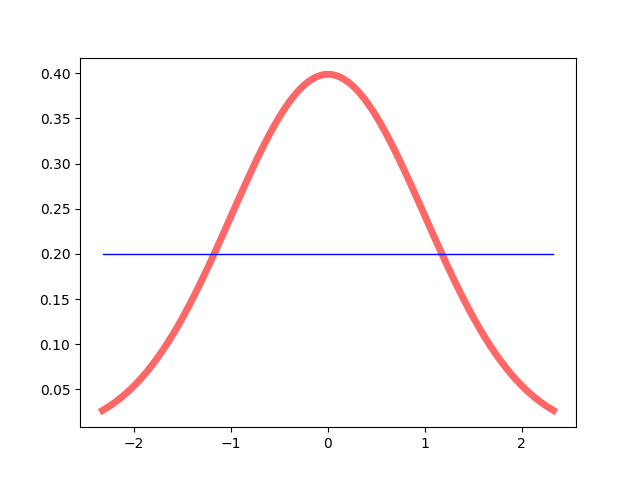

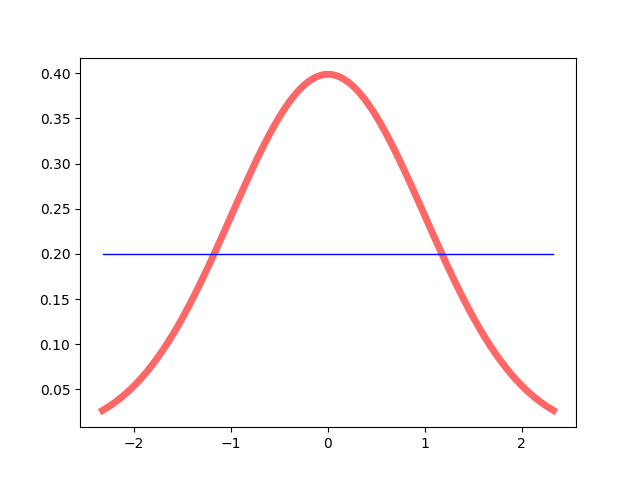

In [2]:
fig, ax = plt.subplots() #ax : contient les primitives qui permet de dessiner
#utiliser plt est un pointeur sur la dernière figure créée, l'utiliser seulement pour plt.subplots !!!!
#Regarder la doc de Axes 
x = np.linspace(norm.ppf(0.01),
                norm.ppf(0.99), 100)

ax.plot(x, norm.pdf(x),
       'r-', lw=5, alpha=0.6)

ax.plot(x, np.full(len(x), 0.2),
       'b-', lw=1)

fig.show()

In [17]:
from xml.etree.ElementTree import parse, dump
# Parse the E.Coli proteome XML Document
tree = parse(os.path.join(os.path.dirname("__file__"), 'data/uniprot-proteome_UP000000625.xml'))
root = tree.getroot()
ns = '{http://uniprot.org/uniprot}' # MANDATORY PREFIX FOR ANY SEARCH within document
# Store all entries aka proteins in a list of xml nodes
proteins = root.findall(ns + 'entry')
# Display the xml subtree of the first protein 
dump(proteins[0])

<ns0:entry xmlns:ns0="http://uniprot.org/uniprot" dataset="Swiss-Prot" created="1989-10-01" modified="2020-08-12" version="166">
<ns0:accession>P11446</ns0:accession>
<ns0:accession>Q2M8Q3</ns0:accession>
<ns0:name>ARGC_ECOLI</ns0:name>
<ns0:protein>
<ns0:recommendedName>
<ns0:fullName evidence="1 4">N-acetyl-gamma-glutamyl-phosphate reductase</ns0:fullName>
<ns0:shortName evidence="1 4">AGPR</ns0:shortName>
<ns0:ecNumber evidence="1 2">1.2.1.38</ns0:ecNumber>
</ns0:recommendedName>
<ns0:alternativeName>
<ns0:fullName evidence="1 3">N-acetyl-glutamate semialdehyde dehydrogenase</ns0:fullName>
<ns0:shortName evidence="1 3">NAGSA dehydrogenase</ns0:shortName>
</ns0:alternativeName>
</ns0:protein>
<ns0:gene>
<ns0:name type="primary" evidence="1">argC</ns0:name>
<ns0:name type="ordered locus">b3958</ns0:name>
<ns0:name type="ordered locus">JW3930</ns0:name>
</ns0:gene>
<ns0:organism>
<ns0:name type="scientific">Escherichia coli (strain K12)</ns0:name>
<ns0:dbReference type="NCBI Taxonomy" 

In [15]:
# Find the xml subtree of a protein with accession "P31224"
for entry in proteins:
    accessions = entry.findall(ns+"accession")
    for acc in accessions:
        if acc.text == "P31224":
            dump(entry)
            break

<ns0:entry xmlns:ns0="http://uniprot.org/uniprot" dataset="Swiss-Prot" created="1993-07-01" modified="2020-08-12" version="187">
<ns0:accession>P31224</ns0:accession>
<ns0:accession>Q2MBW5</ns0:accession>
<ns0:name>ACRB_ECOLI</ns0:name>
<ns0:protein>
<ns0:recommendedName>
<ns0:fullName>Multidrug efflux pump subunit AcrB</ns0:fullName>
</ns0:recommendedName>
<ns0:alternativeName>
<ns0:fullName>AcrAB-TolC multidrug efflux pump subunit AcrB</ns0:fullName>
</ns0:alternativeName>
<ns0:alternativeName>
<ns0:fullName>Acridine resistance protein B</ns0:fullName>
</ns0:alternativeName>
</ns0:protein>
<ns0:gene>
<ns0:name type="primary">acrB</ns0:name>
<ns0:name type="synonym">acrE</ns0:name>
<ns0:name type="ordered locus">b0462</ns0:name>
<ns0:name type="ordered locus">JW0451</ns0:name>
</ns0:gene>
<ns0:organism>
<ns0:name type="scientific">Escherichia coli (strain K12)</ns0:name>
<ns0:dbReference type="NCBI Taxonomy" id="83333" />
<ns0:lineage>
<ns0:taxon>Bacteria</ns0:taxon>
<ns0:taxon>Proteo

### 1. Ouvrir le tableau de données

In [50]:
df = pd.read_csv("data/TCL_wt1.tsv", sep="\t", na_values = "#VALEUR!")
df

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
0,P75936,Basal-body rod modification protein FlgD OS=Es...,flgD,0.075817,-3.721335,0.000055,4.260067
1,P76231,Uncharacterized protein YeaC OS=Escherichia co...,yeaC,0.092810,-3.429569,0.000351,3.454627
2,P0A8S9,Flagellar transcriptional regulator FlhD OS=Es...,flhD,0.102614,-3.284695,0.000027,4.571899
3,P0CE48,Elongation factor Tu 2 OS=Escherichia coli (st...,tufB,NaN,NaN,NaN,NaN
4,P05706,PTS system glucitol/sorbitol-specific EIIA com...,srlB,0.108497,-3.204277,0.019963,1.699768
...,...,...,...,...,...,...,...
2019,P24240,6-phospho-beta-glucosidase AscB OS=Escherichia...,ascB,NaN,NaN,NaN,NaN
2020,P0A917,Outer membrane protein X OS=Escherichia coli (...,ompX,1.579739,0.659686,0.002226,2.652391
2021,P02931,Outer membrane protein F OS=Escherichia coli (...,ompF,1.754902,0.811390,0.000068,4.164956
2022,P0AB40,Multiple stress resistance protein BhsA OS=Esc...,bhsA,1.798039,0.846424,0.035928,1.444561


In [51]:
type(df)

pandas.core.frame.DataFrame

In [6]:
df.shape

(2024, 7)

In [7]:
df.head()

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
0,P75936,Basal-body rod modification protein FlgD OS=Es...,flgD,0.075816993,-3.721334942,0.000055,4.260067469
1,P76231,Uncharacterized protein YeaC OS=Escherichia co...,yeaC,0.092810458,-3.429568818,0.000351,3.45462743
2,P0A8S9,Flagellar transcriptional regulator FlhD OS=Es...,flhD,0.102614379,-3.284695189,0.000027,4.571899347
3,P0CE48,Elongation factor Tu 2 OS=Escherichia coli (st...,tufB,#VALEUR!,#VALEUR!,NaN,#VALEUR!
4,P05706,PTS system glucitol/sorbitol-specific EIIA com...,srlB,0.108496732,-3.204276506,0.019963,1.699767669


In [8]:
df.tail()

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
2019,P24240,6-phospho-beta-glucosidase AscB OS=Escherichia...,ascB,#VALEUR!,#VALEUR!,NaN,#VALEUR!
2020,P0A917,Outer membrane protein X OS=Escherichia coli (...,ompX,1.579738562,0.65968582,0.002226,2.652390664
2021,P02931,Outer membrane protein F OS=Escherichia coli (...,ompF,1.754901961,0.811390435,0.000068,4.16495627
2022,P0AB40,Multiple stress resistance protein BhsA OS=Esc...,bhsA,1.798039216,0.846424487,0.035928,1.444561032
2023,P76042,Putative ABC transporter periplasmic-binding p...,ycjN,#VALEUR!,#VALEUR!,NaN,#VALEUR!


In [9]:
df.columns

Index(['Accession', 'Description', 'Gene Symbol',
       'Corrected Abundance ratio (1.53)', 'Log2 Corrected Abundance Ratio',
       'Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)',
       '-LOG10 Adj.P-val'],
      dtype='object')

In [52]:
df.dtypes

Accession                                                        object
Description                                                      object
Gene Symbol                                                      object
Corrected Abundance ratio (1.53)                                float64
Log2 Corrected Abundance Ratio                                  float64
Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)    float64
-LOG10 Adj.P-val                                                float64
dtype: object

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2024 entries, 0 to 2023
Data columns (total 7 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   Accession                                                     2024 non-null   object 
 1   Description                                                   2024 non-null   object 
 2   Gene Symbol                                                   2017 non-null   object 
 3   Corrected Abundance ratio (1.53)                              1892 non-null   float64
 4   Log2 Corrected Abundance Ratio                                1892 non-null   float64
 5   Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)  1750 non-null   float64
 6   -LOG10 Adj.P-val                                              1750 non-null   float64
dtypes: float64(4), object(3)
memory usage: 110.8+ KB


In [15]:
df.describe()

,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)
count,1.750000e+03
mean,8.238311e-01
std,3.506349e-01
min,1.034030e-08
25%,1.000000e+00
50%,1.000000e+00
75%,1.000000e+00
max,1.000000e+00


In [16]:
df.dropna()

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
0,P75936,Basal-body rod modification protein FlgD OS=Es...,flgD,0.075816993,-3.721334942,0.000055,4.260067469
1,P76231,Uncharacterized protein YeaC OS=Escherichia co...,yeaC,0.092810458,-3.429568818,0.000351,3.45462743
2,P0A8S9,Flagellar transcriptional regulator FlhD OS=Es...,flhD,0.102614379,-3.284695189,0.000027,4.571899347
4,P05706,PTS system glucitol/sorbitol-specific EIIA com...,srlB,0.108496732,-3.204276506,0.019963,1.699767669
5,P29744,Flagellar hook-associated protein 3 OS=Escheri...,flgL,0.124183007,-3.009460329,0.036746,1.434786589
...,...,...,...,...,...,...,...
2011,P77330,Prophage lipoprotein Bor homolog OS=Escherichi...,borD,1.535947712,0.619129104,0.310725,0.507623276
2016,P02930,Outer membrane protein TolC OS=Escherichia col...,tolC,1.552287582,0.634395861,0.013373,1.873756665
2020,P0A917,Outer membrane protein X OS=Escherichia coli (...,ompX,1.579738562,0.65968582,0.002226,2.652390664
2021,P02931,Outer membrane protein F OS=Escherichia coli (...,ompF,1.754901961,0.811390435,0.000068,4.16495627


In [25]:
columns_to_check = ['Corrected Abundance ratio (1.53)', 'Log2 Corrected Abundance Ratio',
       'Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)',
       '-LOG10 Adj.P-val']
#set_non_float_values = set()
for column in columns_to_check:
    for i, value in enumerate(df[column]):
        try : 
            float(value)
        except ValueError:
            df[column][i] = np.nan
            #if value not in set_non_float_values:
                #set_non_float_values.add(value)

In [27]:
values = df[['Description', 'Gene Symbol']]
values

,Description,Gene Symbol
0,Basal-body rod modification protein FlgD OS=Es...,flgD
1,Uncharacterized protein YeaC OS=Escherichia co...,yeaC
2,Flagellar transcriptional regulator FlhD OS=Es...,flhD
3,Elongation factor Tu 2 OS=Escherichia coli (st...,tufB
4,PTS system glucitol/sorbitol-specific EIIA com...,srlB
...,...,...
2019,6-phospho-beta-glucosidase AscB OS=Escherichia...,ascB
2020,Outer membrane protein X OS=Escherichia coli (...,ompX
2021,Outer membrane protein F OS=Escherichia coli (...,ompF
2022,Multiple stress resistance protein BhsA OS=Esc...,bhsA


In [28]:
values.dtypes

Description    object
Gene Symbol    object
dtype: object

In [29]:
type(values)

pandas.core.frame.DataFrame

In [44]:
values.head()

,Description,Gene Symbol
0,Basal-body rod modification protein FlgD OS=Es...,flgD
1,Uncharacterized protein YeaC OS=Escherichia co...,yeaC
2,Flagellar transcriptional regulator FlhD OS=Es...,flhD
3,Elongation factor Tu 2 OS=Escherichia coli (st...,tufB
4,PTS system glucitol/sorbitol-specific EIIA com...,srlB


In [56]:
values.iloc[:,-1]

0       flgD
1       yeaC
2       flhD
3       tufB
4       srlB
        ... 
2019    ascB
2020    ompX
2021    ompF
2022    bhsA
2023    ycjN
Name: Gene Symbol, Length: 2024, dtype: object

In [57]:
df.head().iloc[:,[0,2,3]]

,Accession,Gene Symbol,Corrected Abundance ratio (1.53)
0,P75936,flgD,0.075817
1,P76231,yeaC,0.092810
2,P0A8S9,flhD,0.102614
3,P0CE48,tufB,NaN
4,P05706,srlB,0.108497


In [60]:
pd.read_csv('data/TCL_wt1.tsv', sep="\t",  dtype = {'Accession': str, 'Description': str, 'Gene Symbol': str, 
                                                 'Corrected Abundance ratio (1.53)': float,  'Log2 Corrected Abundance Ratio': float, 
                                                 'Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)': float, '-LOG10 Adj.P-val': float}, na_values = "#VALEUR!")

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
0,P75936,Basal-body rod modification protein FlgD OS=Es...,flgD,0.075817,-3.721335,0.000055,4.260067
1,P76231,Uncharacterized protein YeaC OS=Escherichia co...,yeaC,0.092810,-3.429569,0.000351,3.454627
2,P0A8S9,Flagellar transcriptional regulator FlhD OS=Es...,flhD,0.102614,-3.284695,0.000027,4.571899
3,P0CE48,Elongation factor Tu 2 OS=Escherichia coli (st...,tufB,NaN,NaN,NaN,NaN
4,P05706,PTS system glucitol/sorbitol-specific EIIA com...,srlB,0.108497,-3.204277,0.019963,1.699768
...,...,...,...,...,...,...,...
2019,P24240,6-phospho-beta-glucosidase AscB OS=Escherichia...,ascB,NaN,NaN,NaN,NaN
2020,P0A917,Outer membrane protein X OS=Escherichia coli (...,ompX,1.579739,0.659686,0.002226,2.652391
2021,P02931,Outer membrane protein F OS=Escherichia coli (...,ompF,1.754902,0.811390,0.000068,4.164956
2022,P0AB40,Multiple stress resistance protein BhsA OS=Esc...,bhsA,1.798039,0.846424,0.035928,1.444561


In [61]:
df = df.astype({'Log2 Corrected Abundance Ratio': float, '-LOG10 Adj.P-val': float } )

In [62]:
df.loc[(df['-LOG10 Adj.P-val'] > 0 )  & (df['Log2 Corrected Abundance Ratio'] > 0.0 ) ]

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
1938,P68919,50S ribosomal protein L25 OS=Escherichia coli ...,rplY,1.010458,0.015009,2.035974e-01,0.691228
1939,P0ACG1,DNA-binding protein StpA OS=Escherichia coli (...,stpA,1.013072,0.018737,1.936673e-01,0.712944
1940,P0A903,Outer membrane protein assembly factor BamC OS...,bamC,1.020915,0.029863,3.957145e-01,0.402618
1945,P0ADE4,Translocation and assembly module subunit TamA...,tamA; ytfM,1.024183,0.034474,2.625522e-03,2.580784
1946,P02943,Maltoporin OS=Escherichia coli (strain K12) OX...,lamB,1.030065,0.042736,3.135847e-03,2.503645
1947,P77774,Outer membrane protein assembly factor BamB OS...,bamB,1.035294,0.050041,4.857703e-01,0.313569
1948,P0A940,Outer membrane protein assembly factor BamA OS...,bamA,1.039869,0.056402,1.228502e-01,0.910624
1955,P0AEQ1,Protein GlcG OS=Escherichia coli (strain K12) ...,glcG,1.050327,0.070838,2.177041e-02,1.662133
1957,P09169,Protease 7 OS=Escherichia coli (strain K12) OX...,ompT,1.052288,0.073529,1.085198e-01,0.964491
1962,P05825,Ferrienterobactin receptor OS=Escherichia coli...,fepA,1.076471,0.106309,1.524348e-02,1.816916


In [63]:
df.loc[ df['Gene Symbol'].isin(['fadR', 'arcA'] ) ]

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
1862,P0A8V6,Fatty acid metabolism regulator protein OS=Esc...,fadR,0.901307,-0.149909,0.000351,3.454627
1898,P0A9Q1,Aerobic respiration control protein ArcA OS=Es...,arcA,0.931373,-0.102570,0.000136,3.866640


### Analyse protéomique

In [116]:
df = pd.read_csv('data/TCL_wt1.tsv', sep="\t", na_values = "#VALEUR!") #keep_default_na = False)

In [87]:
#df = df.astype({'Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)': float} )

In [117]:
df.dtypes

Accession                                                        object
Description                                                      object
Gene Symbol                                                      object
Corrected Abundance ratio (1.53)                                float64
Log2 Corrected Abundance Ratio                                  float64
Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)    float64
-LOG10 Adj.P-val                                                float64
dtype: object

In [118]:
df = df.dropna()

(array([  3.,   4.,   4.,  31.,  74., 187., 551., 831.,  50.,  11.]),
 array([-3.72133494, -3.264559  , -2.80778306, -2.35100711, -1.89423117,
        -1.43745523, -0.98067928, -0.52390334, -0.0671274 ,  0.38964854,
         0.84642449]),
 <BarContainer object of 10 artists>)

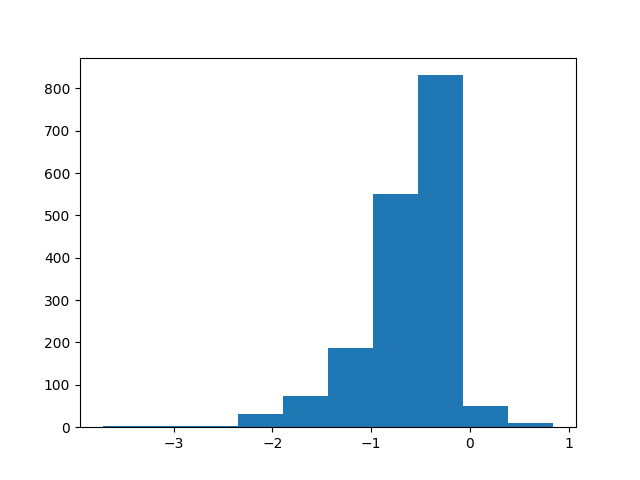

In [122]:
fig, ax = plt.subplots()
ax.hist(df.iloc[:,4], label = "Log2 Corrected Abundance Ratio histogram")
#ax.legend(title="Log2 Corrected Abundance Ratio histogram")

In [120]:
mu = np.mean(df.iloc[:,4])
sigma = np.std(df.iloc[:,4])
mu, sigma

(np.float64(-0.63862621564433), np.float64(0.47062451611275274))

In [119]:
df.shape

(1746, 7)

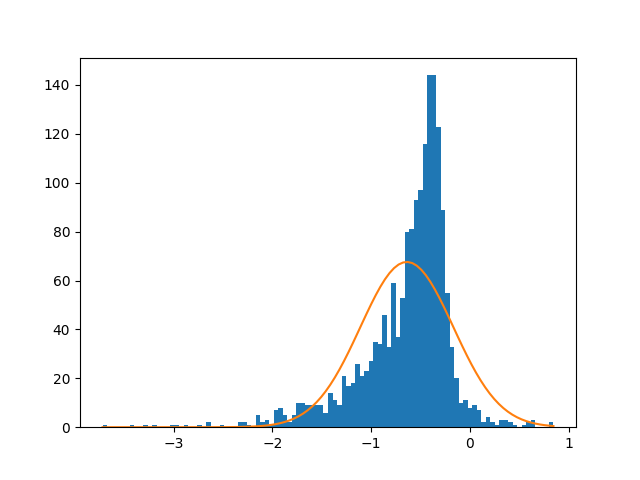

In [ ]:
# df.iloc[:,4] est le vecteur des valeurs d'abondance
fig, ax = plt.subplots()
hist = ax.hist(df.iloc[:,4], bins=100) # draw histogram
x = np.linspace(min(df.iloc[:,4]), max(df.iloc[:,4]), 100) # generate PDF domain points
dx = hist[1][1] - hist[1][0] # Get single value bar height
scale = len(df.iloc[:,4])*dx # scale accordingly
ax.plot(x, norm.pdf(x, mu, sigma)*scale) # compute theoritical PDF and draw it

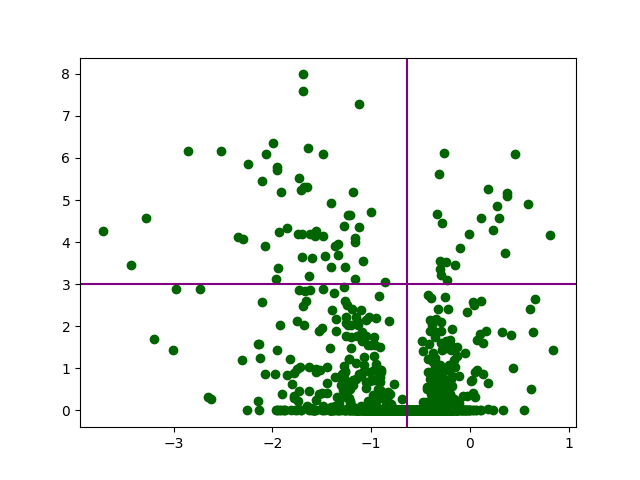

In [145]:
#scatter plot -- volcano plot
fig, ax = plt.subplots()
scatter = ax.scatter(df.iloc[:,4], df.iloc[:,6], color = "darkgreen")  
ax.axhline(y=-np.log10(0.001), color='purple', linestyle='-')
ax.axvline(x=mu, color='purple', linestyle='-')

In [131]:
mu

np.float64(-0.63862621564433)

In [123]:
df

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
0,P75936,Basal-body rod modification protein FlgD OS=Es...,flgD,0.075817,-3.721335,0.000055,4.260067
1,P76231,Uncharacterized protein YeaC OS=Escherichia co...,yeaC,0.092810,-3.429569,0.000351,3.454627
2,P0A8S9,Flagellar transcriptional regulator FlhD OS=Es...,flhD,0.102614,-3.284695,0.000027,4.571899
4,P05706,PTS system glucitol/sorbitol-specific EIIA com...,srlB,0.108497,-3.204277,0.019963,1.699768
5,P29744,Flagellar hook-associated protein 3 OS=Escheri...,flgL,0.124183,-3.009460,0.036746,1.434787
...,...,...,...,...,...,...,...
2011,P77330,Prophage lipoprotein Bor homolog OS=Escherichi...,borD,1.535948,0.619129,0.310725,0.507623
2016,P02930,Outer membrane protein TolC OS=Escherichia col...,tolC,1.552288,0.634396,0.013373,1.873757
2020,P0A917,Outer membrane protein X OS=Escherichia coli (...,ompX,1.579739,0.659686,0.002226,2.652391
2021,P02931,Outer membrane protein F OS=Escherichia coli (...,ompF,1.754902,0.811390,0.000068,4.164956


In [166]:
uniprot_ids = df.loc[(df['-LOG10 Adj.P-val'] > -np.log10(0.001) )  & (df['Log2 Corrected Abundance Ratio'] > mu )].iloc[:,0]

In [167]:
list(uniprot_ids)

['P23721',
 'P77804',
 'P0A6K6',
 'P0A799',
 'P0A7G6',
 'P0A6F3',
 'P25745',
 'P0A6M8',
 'P0A6L0',
 'P0A8V6',
 'P0A9Q1',
 'P02358',
 'P0ACF8',
 'P62399',
 'P0A905',
 'P76506',
 'P13036',
 'P10384',
 'P06971',
 'P0A910',
 'P06996',
 'P76344',
 'P02931']

In [168]:
len(uniprot_ids)

23

In [156]:
from xml.etree.ElementTree import parse, dump

def getAccessionGOTerms(xmlFile, accession):
    tree = parse(xmlFile)
    root = tree.getroot()
    ns = '{http://uniprot.org/uniprot}'

    match_go_terms = []
    proteins = root.findall(ns + 'entry')
    for entry in proteins:
        accessions = entry.findall(ns+"accession")
        current_accessions = [ acc.text for acc in accessions ]
        if not accession in current_accessions:
            continue
        goTerms = entry.findall('{http://uniprot.org/uniprot}dbReference[@type="GO"]')
        #goTerms = xmlEntry.findall(ns +'dbReference[@type="GO"]')
        for goT in goTerms:
            gID   = goT.attrib['id']
            gName = goT.find(ns +'property[@type="term"]').attrib['value']
            match_go_terms.append((gID, gName))
        break
    return match_go_terms
getAccessionGOTerms("./data/uniprot-proteome_UP000000625.xml", "P0A8V6")

[('GO:0005829', 'C:cytosol'),
 ('GO:0003677', 'F:DNA binding'),
 ('GO:0003700', 'F:DNA-binding transcription factor activity'),
 ('GO:0000062', 'F:fatty-acyl-CoA binding'),
 ('GO:0019395', 'P:fatty acid oxidation'),
 ('GO:0045892', 'P:negative regulation of transcription, DNA-templated'),
 ('GO:0045723', 'P:positive regulation of fatty acid biosynthetic process'),
 ('GO:0045893', 'P:positive regulation of transcription, DNA-templated'),
 ('GO:0019217', 'P:regulation of fatty acid metabolic process')]

In [157]:
info = getAccessionGOTerms("./data/uniprot-proteome_UP000000625.xml", "P0A8V6")

In [169]:
dict_GO = {} 
for uniprot_id in uniprot_ids : 
    list_info = getAccessionGOTerms("./data/uniprot-proteome_UP000000625.xml", uniprot_id)
    dict_GO[uniprot_id] =  {}
    for info in list_info:
        dict_GO[uniprot_id][info[0]] = info[1]

In [162]:
dict_GO

{'P23721': {'GO:0005737': 'C:cytoplasm',
  'GO:0005829': 'C:cytosol',
  'GO:0004648': 'F:O-phospho-L-serine:2-oxoglutarate aminotransferase activity',
  'GO:0030170': 'F:pyridoxal phosphate binding',
  'GO:0006564': 'P:L-serine biosynthetic process',
  'GO:0006563': 'P:L-serine metabolic process',
  'GO:0033359': 'P:lysine biosynthetic process via diaminopimelate and N-succinyl-2-amino-6-ketopimelate',
  'GO:0042823': 'P:pyridoxal phosphate biosynthetic process',
  'GO:0008615': 'P:pyridoxine biosynthetic process'},
 'P77804': {'GO:0005886': 'C:plasma membrane',
  'GO:0042802': 'F:identical protein binding'},
 'P0A6F3': {'GO:0005829': 'C:cytosol',
  'GO:0005524': 'F:ATP binding',
  'GO:0004370': 'F:glycerol kinase activity',
  'GO:0042802': 'F:identical protein binding',
  'GO:0046872': 'F:metal ion binding',
  'GO:0008270': 'F:zinc ion binding',
  'GO:0006974': 'P:cellular response to DNA damage stimulus',
  'GO:0019563': 'P:glycerol catabolic process',
  'GO:0006071': 'P:glycerol met

In [163]:
dict_GO_2 = {}
for uniprot_id, dict_description in dict_GO.items():
    for k, v in  dict_description.items():
        if k not in dict_GO_2.keys():
            dict_GO_2[k] = {'ID' : k, 'name' : v, 'carried_by' : [uniprot_id]}
        else : 
            dict_GO_2[k]['carried_by'].append(uniprot_id)

In [164]:
dict_GO_2

{'GO:0005737': {'ID': 'GO:0005737',
  'name': 'C:cytoplasm',
  'carried_by': ['P23721']},
 'GO:0005829': {'ID': 'GO:0005829',
  'name': 'C:cytosol',
  'carried_by': ['P23721',
   'P0A6F3',
   'P25745',
   'P02358',
   'P0ACF8',
   'P62399',
   'P76344']},
 'GO:0004648': {'ID': 'GO:0004648',
  'name': 'F:O-phospho-L-serine:2-oxoglutarate aminotransferase activity',
  'carried_by': ['P23721']},
 'GO:0030170': {'ID': 'GO:0030170',
  'name': 'F:pyridoxal phosphate binding',
  'carried_by': ['P23721']},
 'GO:0006564': {'ID': 'GO:0006564',
  'name': 'P:L-serine biosynthetic process',
  'carried_by': ['P23721']},
 'GO:0006563': {'ID': 'GO:0006563',
  'name': 'P:L-serine metabolic process',
  'carried_by': ['P23721']},
 'GO:0033359': {'ID': 'GO:0033359',
  'name': 'P:lysine biosynthetic process via diaminopimelate and N-succinyl-2-amino-6-ketopimelate',
  'carried_by': ['P23721']},
 'GO:0042823': {'ID': 'GO:0042823',
  'name': 'P:pyridoxal phosphate biosynthetic process',
  'carried_by': ['P23

In [ ]:
#Obtention des paramètres du modèle 
